# Decision Tree Analysis for SOC Logs

This notebook trains a Decision Tree classifier on SOC network data to classify connections as either 'Reconnaissance' or 'none' (normal traffic).
It uses the same data preparation and feature engineering as the Logistic Regression model for consistency.

In [49]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import train_test_split
import seaborn as sns

In [50]:
DATA_PATH = Path("./Datasets/part-00000-0af89d10-df53-44fd-b124-a8a496fd5023-c000(2).csv")
MODEL_PATH = Path("./Models/decision_tree_model.joblib")
TARGET_COLUMN = "mitre_attack_tactics"
# EXCLUDE_COLUMNS = {
#     "dest_ip",
#     "src_ip",
#     "uid",
#     "community_id",
#     "datetime",
#     "ts",
# }

In [51]:
def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        if str(path).startswith('/') and not str(path).startswith('/content/'):
            corrected_path = Path("/content") / path.name
            if corrected_path.exists():
                print(f"Correcting data path from '{path}' to '{corrected_path}'")
                path = corrected_path
            else:
                raise FileNotFoundError(f"Data file not found: {path} and also not found at {corrected_path}")
        else:
            raise FileNotFoundError(f"Data file not found: {path}")

    df = pd.read_csv(path)
    print(f"Loaded {len(df):,} rows and {len(df.columns):,} columns.")
    return df

In [52]:
def prepare_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, dict]:
    if TARGET_COLUMN not in df.columns:
        raise ValueError(f"Target column '{TARGET_COLUMN}' not found in input CSV.")

    df = df.copy()
    excluded_actual = EXCLUDE_COLUMNS.intersection(df.columns)
    df = df.drop(columns=excluded_actual, errors="ignore")
    df = df.dropna(subset=[TARGET_COLUMN])

    y = df[TARGET_COLUMN].astype(str).copy()
    X = df.drop(columns=[TARGET_COLUMN])

    # Convert values that look numeric into numeric columns
    for col in X.columns:
        if X[col].dtype == object:
            converted = pd.to_numeric(X[col], errors="coerce")
            if converted.notna().sum() > len(X) * 0.75:
                X[col] = converted

    # --- Feature Engineering: Create new features ---
    # Total packets and bytes
    X['total_pkts'] = X['orig_pkts'] + X['resp_pkts']
    X['total_bytes'] = X['orig_bytes'] + X['resp_bytes']

    # Packet and byte ratios (handling division by zero)
    X['pkt_ratio'] = X['resp_pkts'] / X['total_pkts'].replace(0, np.nan)
    X['byte_ratio'] = X['resp_bytes'] / X['total_bytes'].replace(0, np.nan)
    X[['pkt_ratio', 'byte_ratio']] = X[['pkt_ratio', 'byte_ratio']].fillna(0)

    # Packet and byte rates (handling division by zero and infinite values)
    X['pkt_rate'] = X['total_pkts'] / X['duration'].replace(0, np.nan)
    X['byte_rate'] = X['total_bytes'] / X['duration'].replace(0, np.nan)
    X[['pkt_rate', 'byte_rate']] = X[['pkt_rate', 'byte_rate']].replace([np.inf, -np.inf], 0).fillna(0)
    # --- End Feature Engineering ---

    # Encode categorical features
    encoders = {}
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]) or pd.api.types.is_bool_dtype(X[col]):
            encoder = LabelEncoder()
            X[col] = encoder.fit_transform(X[col].astype(str))
            encoders[col] = encoder

    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    print("Using numeric features:", numeric_features)
    print(f"Encoded categorical features: {list(encoders.keys())}")

    if not numeric_features:
        raise ValueError("No valid numeric features found for training.")

    print("\n--- Feature Summary ---")
    print(f"Target column: {TARGET_COLUMN}")
    print(f"Columns explicitly excluded: {list(excluded_actual)}")
    print(f"Final set of features used: {numeric_features}")
    print("-----------------------")

    return X, y, encoders

In [53]:
def plot_results(y_test: np.ndarray, y_pred: np.ndarray, label_names: list[str], encoded_labels: list[int]) -> None:
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

    # Bar plot: actual vs predicted (using encoded numeric labels)
    actual_counts = [np.sum(y_test == label) for label in encoded_labels]
    predicted_counts = [np.sum(y_pred == label) for label in encoded_labels]
    x = np.arange(len(encoded_labels))
    width = 0.35

    axes[0].bar(x - width / 2, actual_counts, width, label="Actual")
    axes[0].bar(x + width / 2, predicted_counts, width, label="Predicted")
    axes[0].set_title("Class distribution: actual vs predicted")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(label_names, rotation=45, ha="right")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.4)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=encoded_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=axes[1], cmap=plt.cm.Blues, xticks_rotation=45)
    axes[1].set_title("Confusion Matrix")

    fig.tight_layout()
    plt.show()

In [54]:
def main() -> tuple[DecisionTreeClassifier, dict, pd.DataFrame]:
    df = load_data(DATA_PATH)
    X, y, encoders = prepare_features(df)

    if X.empty or y.empty:
        raise ValueError("No data available after preprocessing.")

    # Encode target variable
    target_encoder = LabelEncoder()
    y_encoded = target_encoder.fit_transform(y)
    encoders['target'] = target_encoder

    stratify = y_encoded if len(np.unique(y_encoded)) >= 2 else None
    if stratify is None:
        print("Warning: stratified split disabled because some classes have fewer than 2 samples.")

    x_train, x_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=stratify,
    )

    print("Training Decision Tree model...")
    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
    )
    model.fit(x_train, y_train)

    print("Evaluating model...")
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=target_encoder.classes_, zero_division=0))

    # Feature importances
    feature_importances = sorted(
        zip(X.columns, model.feature_importances_),
        key=lambda x: x[1],
        reverse=True
    )
    print("\nTop 10 Feature Importances:")
    for feature, importance in feature_importances[:10]:
        print(f"  {feature}: {importance:.4f}")

    # Plot results
    labels = sorted(np.unique(y_encoded))
    label_names = target_encoder.classes_
    plot_results(y_test, y_pred, label_names, labels)

    return model, encoders, X

Loaded 23,003 rows and 23 columns.
Using numeric features: ['resp_pkts', 'service', 'orig_ip_bytes', 'local_resp', 'missed_bytes', 'protocol', 'duration', 'conn_state', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'local_orig', 'history', 'resp_bytes', 'src_port', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate']
Encoded categorical features: ['service', 'local_resp', 'protocol', 'conn_state', 'local_orig', 'history']

--- Feature Summary ---
Target column: mitre_attack_tactics
Columns explicitly excluded: ['uid', 'datetime', 'src_ip', 'community_id', 'dest_ip', 'ts']
Final set of features used: ['resp_pkts', 'service', 'orig_ip_bytes', 'local_resp', 'missed_bytes', 'protocol', 'duration', 'conn_state', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'local_orig', 'history', 'resp_bytes', 'src_port', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate']
-----------------------
Training Decision Tree model...

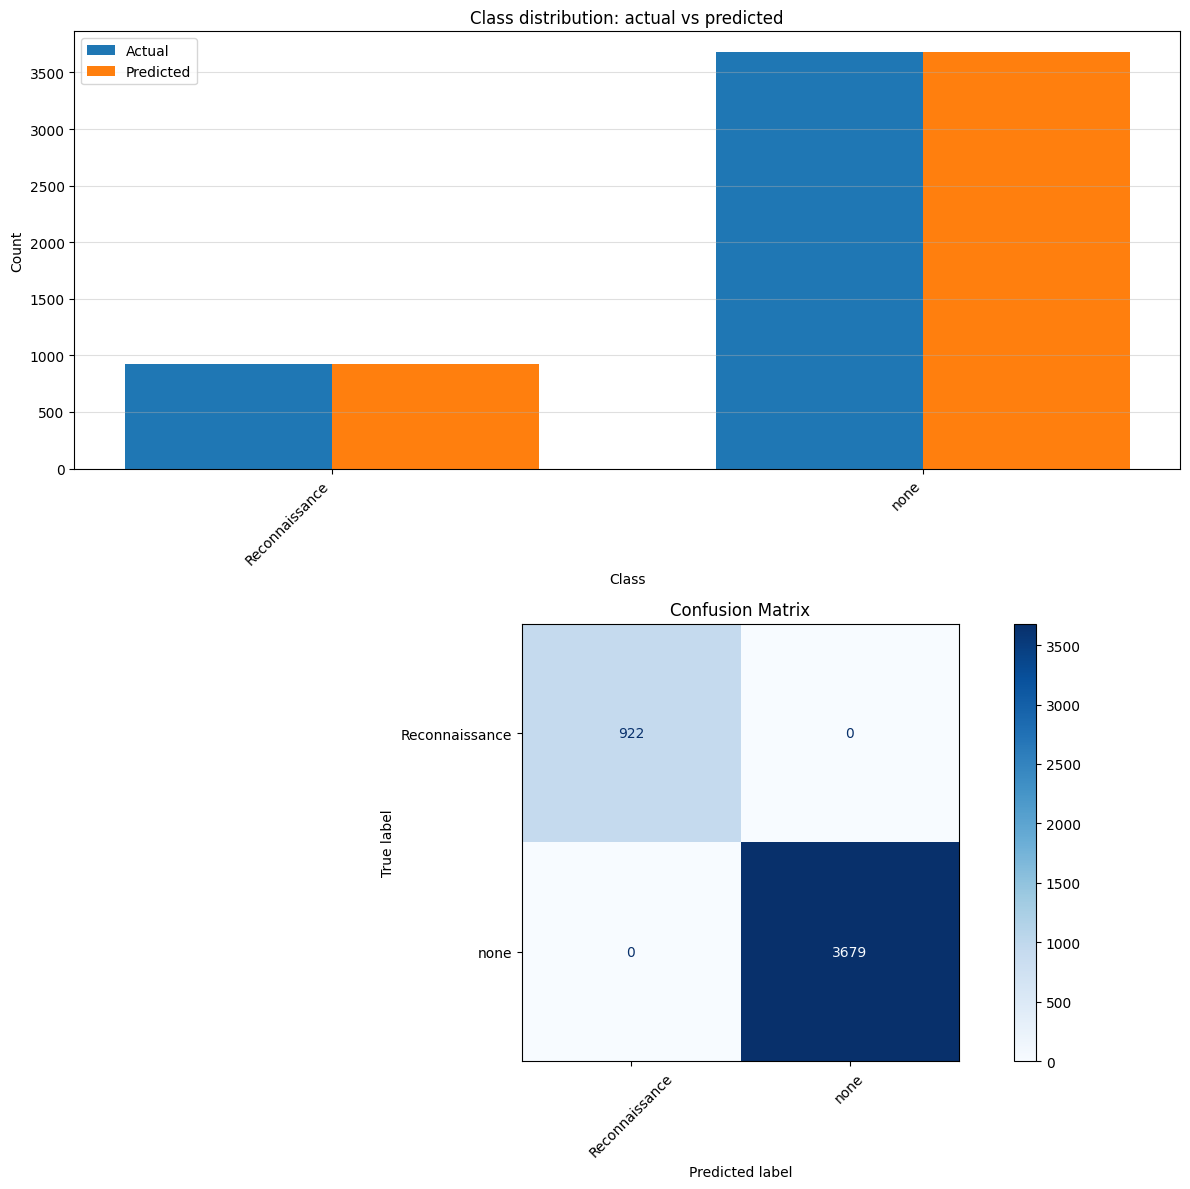

Saved trained model to Models/decision_tree_model.joblib


In [55]:
if __name__ == "__main__":
    model, encoders, X = main()
    import joblib
    # Ensure Models directory exists
    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, MODEL_PATH)
    print(f"Saved trained model to {MODEL_PATH}")

In [56]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained model
print(f"Loading model from {MODEL_PATH}")
model_loaded = joblib.load(MODEL_PATH)

# Make sure X is available from the main() function execution above
# If X is not defined, rerun the main() cell first

# Get feature importances
feature_importances = sorted(
    zip(X.columns, model_loaded.feature_importances_),
    key=lambda x: x[1],
    reverse=True
)

feature_importance_df = pd.DataFrame({
    'Feature': [f for f, _ in feature_importances],
    'Importance': [i for _, i in feature_importances]
})

print("\nTop 15 Feature Importances:")
print(feature_importance_df.head(15))

Loading model from Models/decision_tree_model.joblib

Top 15 Feature Importances:
          Feature  Importance
0        duration    0.725624
1   orig_ip_bytes    0.266291
2       dest_port    0.004353
3      orig_bytes    0.003708
4        src_port    0.000021
5      byte_ratio    0.000003
6       resp_pkts    0.000000
7         service    0.000000
8      local_resp    0.000000
9    missed_bytes    0.000000
10       protocol    0.000000
11     conn_state    0.000000
12      orig_pkts    0.000000
13  resp_ip_bytes    0.000000
14     local_orig    0.000000


/tmp/ipykernel_67601/1104109574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


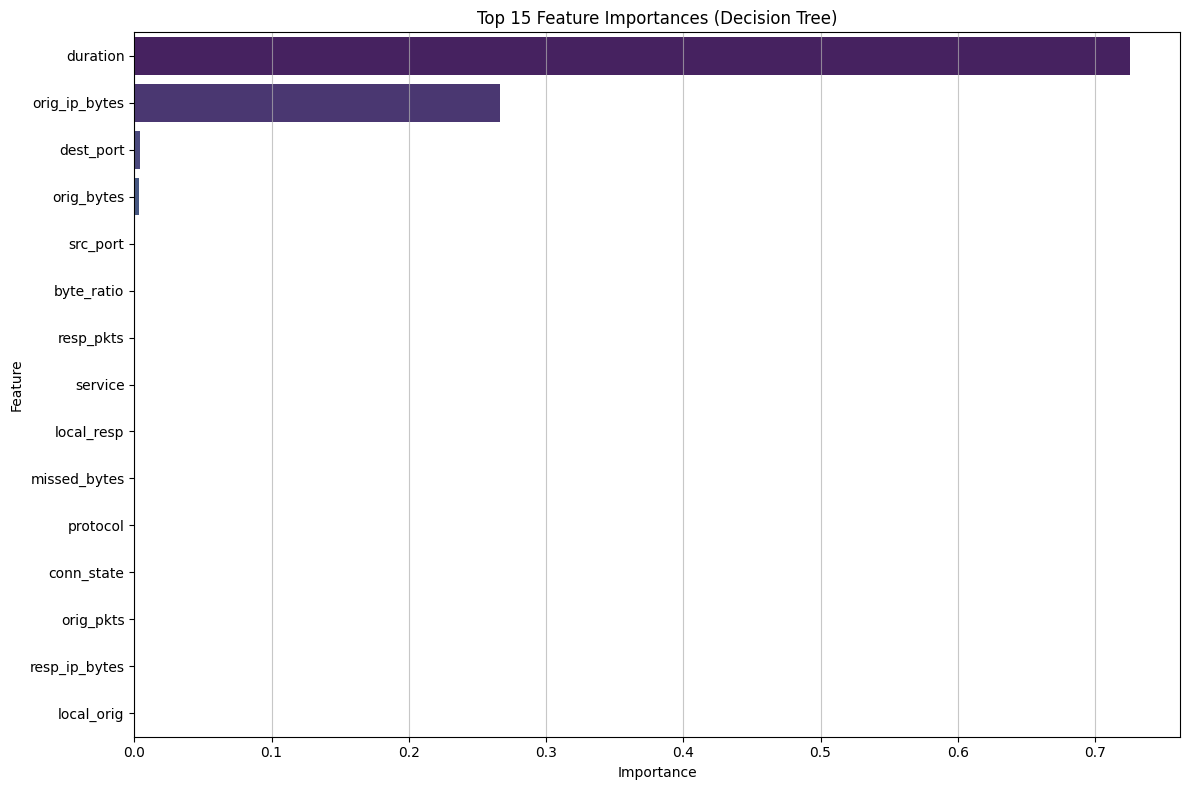

In [57]:
# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.7)
plt.tight_layout()
plt.show()

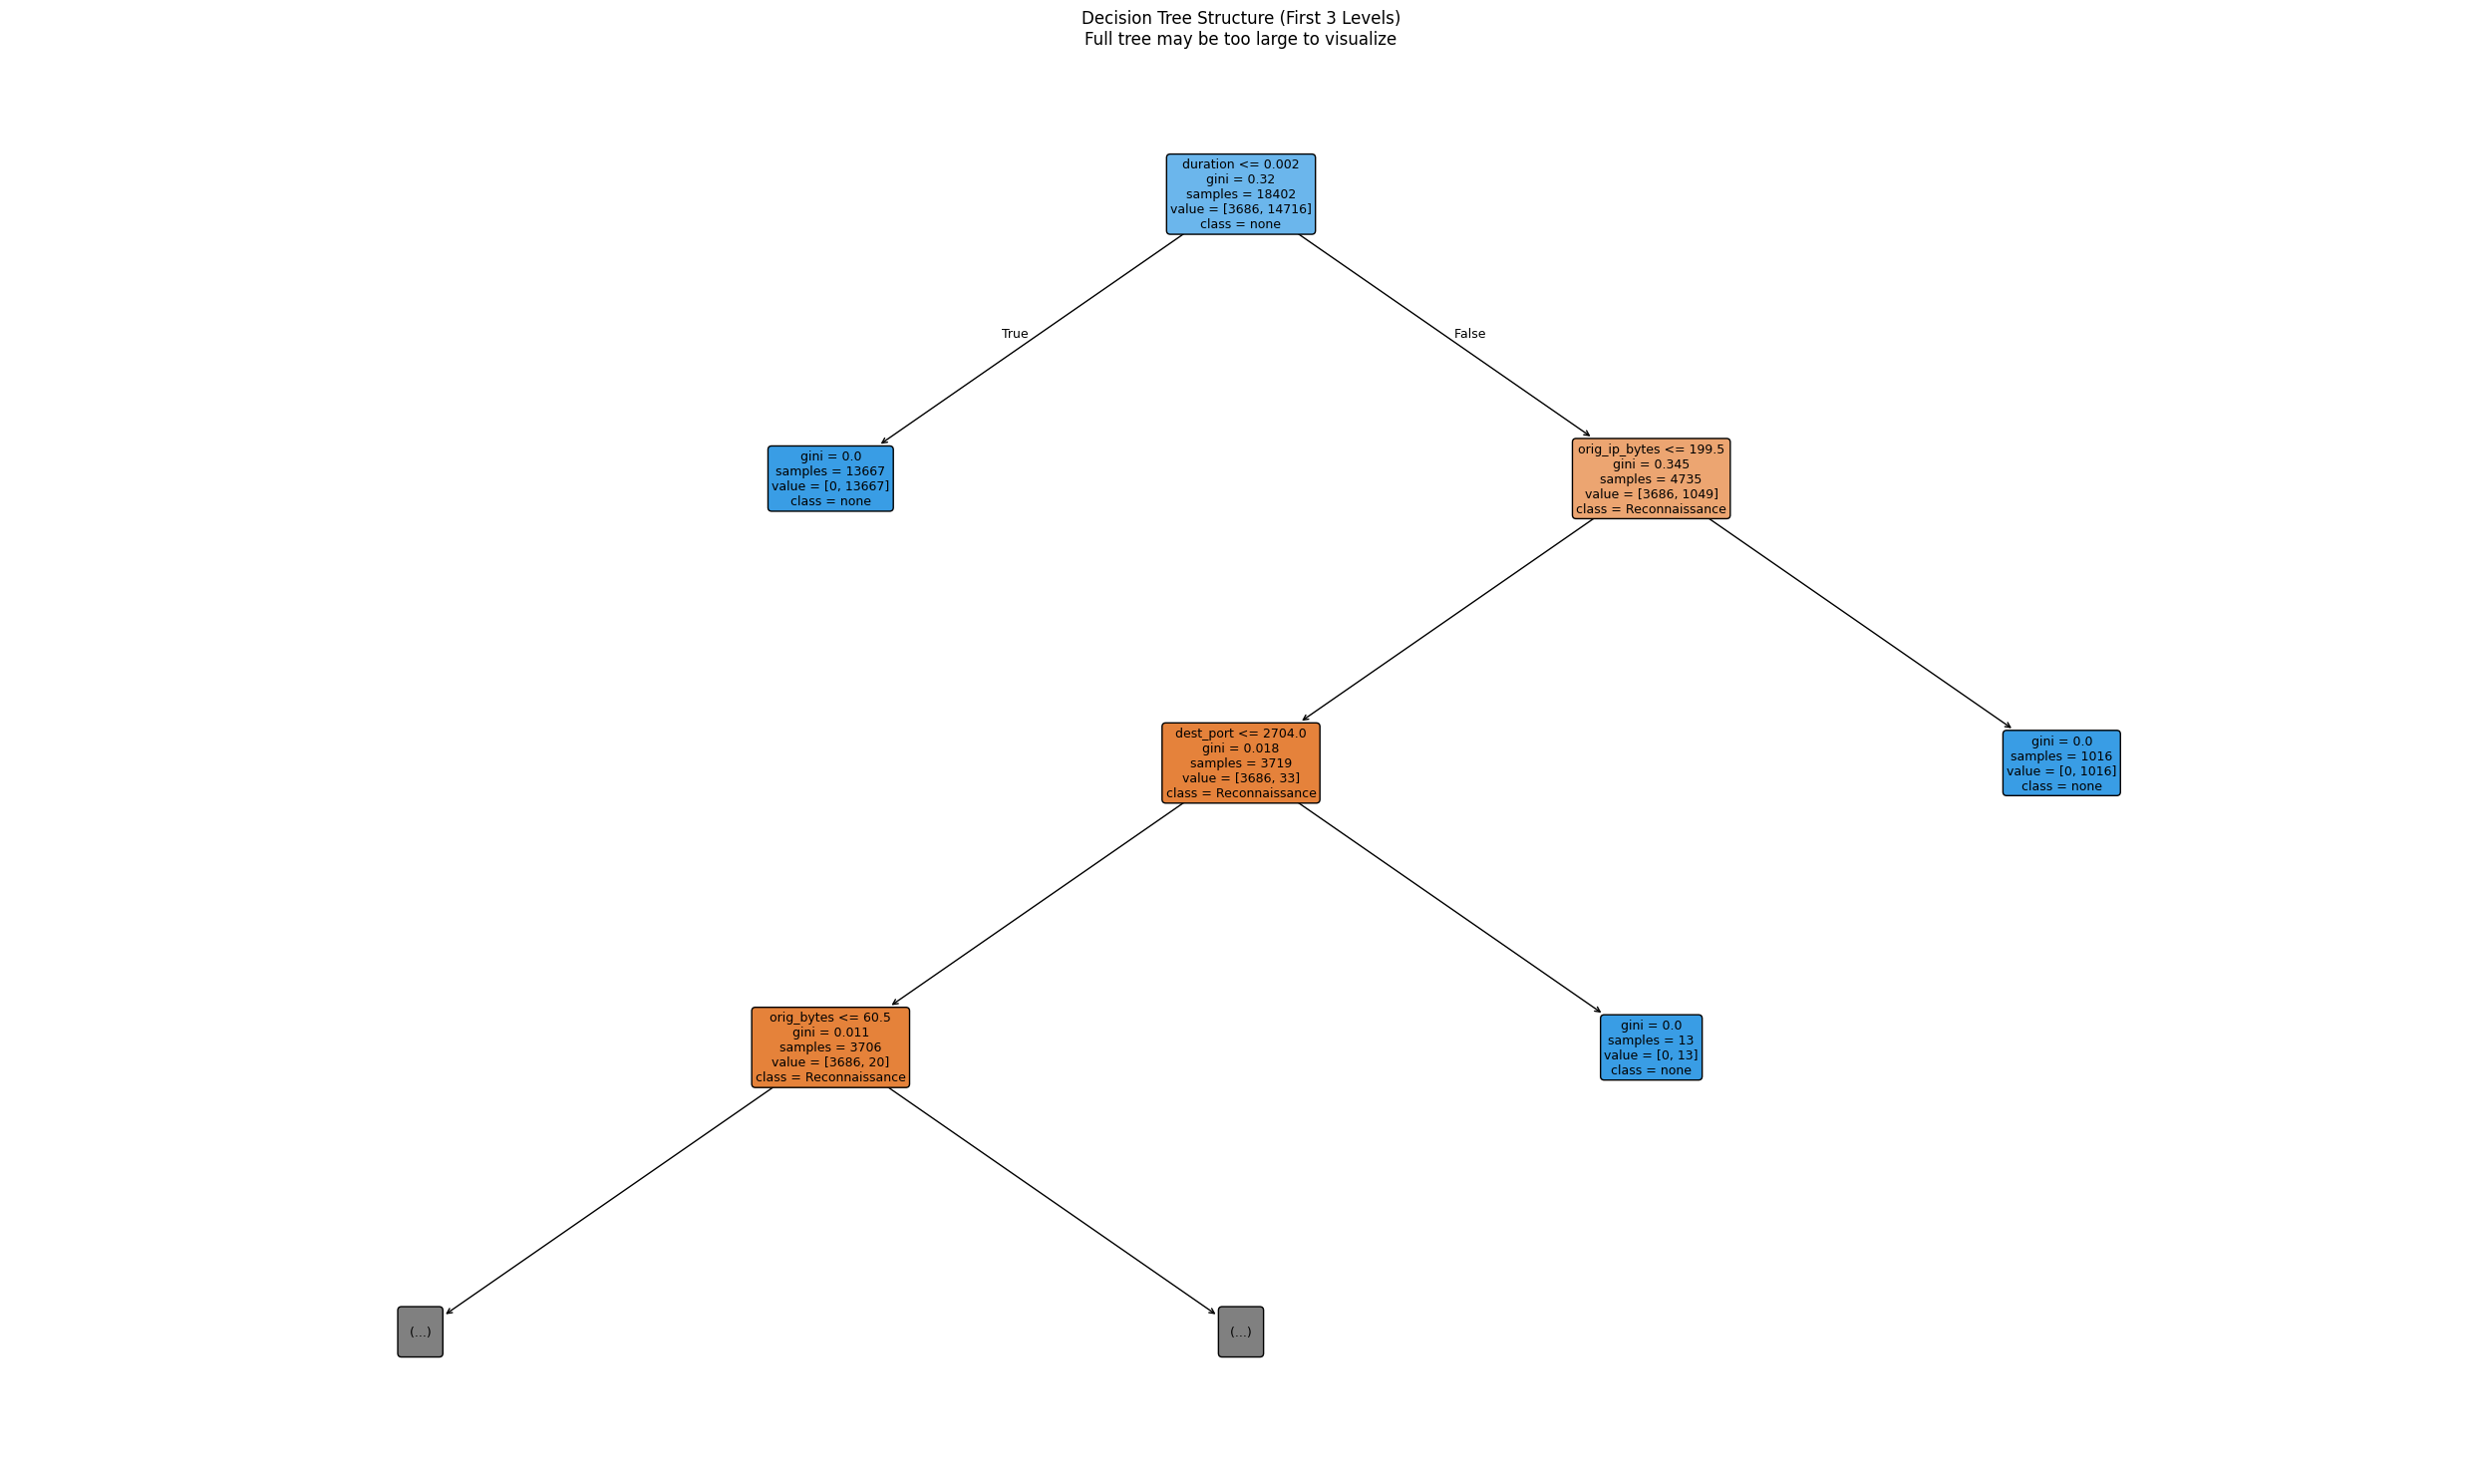

In [58]:
# Plot the decision tree structure (simplified to depth 3 for visibility)
try:
    fig, ax = plt.subplots(figsize=(25, 15))
    plot_tree(
        model_loaded,
        feature_names=X.columns,
        class_names=encoders['target'].classes_,
        filled=True,
        rounded=True,
        fontsize=9,
        ax=ax,
        max_depth=3  # Show only first 3 levels for clarity
    )
    plt.title('Decision Tree Structure (First 3 Levels)\nFull tree may be too large to visualize')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not plot tree: {e}")

## Model Comparison Summary

This Decision Tree model uses:
- **Same data source**: SOC network logs dataset
- **Same target**: `mitre_attack_tactics` (Reconnaissance vs none)
- **Same excluded columns**: dest_ip, src_ip, uid, community_id, datetime, ts
- **Same feature engineering**: total_pkts, total_bytes, pkt_ratio, byte_ratio, pkt_rate, byte_rate

**Key Differences from Logistic Regression**:
- Simpler model without complex preprocessing pipeline
- Handles categorical features naturally after encoding
- Interpretable feature importances based on splits
- Generally faster to train and predict
- Better for identifying non-linear patterns

**Tree Parameters**:
- max_depth: 10 (controls tree depth)
- min_samples_leaf: 5 (minimum samples required to be a leaf node)
- min_samples_split: 10 (minimum samples required to split an internal node)